In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("netflix_dataset.csv")

print("First 10 Rows of Dataset:\n")
df.head(10)


First 10 Rows of Dataset:



,show_id,title,type,release_year,genre,country,rating,duration_min,views_millions
0,s0001,Netflix Title 1,Movie,2010,Documentary,India,6.1,77,184.4
1,s0002,Netflix Title 2,Movie,2023,Drama,USA,5.4,89,126.8
2,s0003,Netflix Title 3,Movie,2016,Documentary,Spain,8.2,113,55.9
3,s0004,Netflix Title 4,TV Show,2010,Romance,Japan,5.7,114,85.7
4,s0005,Netflix Title 5,Movie,2016,Romance,India,5.5,108,25.1
5,s0006,Netflix Title 6,TV Show,2018,Romance,USA,8.3,128,32.1
6,s0007,Netflix Title 7,TV Show,2012,Sci-Fi,India,8.7,139,221.5
7,s0008,Netflix Title 8,TV Show,2016,Documentary,USA,5.2,89,193.5
8,s0009,Netflix Title 9,Movie,2017,Romance,USA,6.7,118,159.3
9,s0010,Netflix Title 10,TV Show,2015,Action,India,5.9,94,175.8


In [5]:
print("\nShape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Shape of Dataset:
(100, 9)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   show_id         100 non-null    str    
 1   title           100 non-null    str    
 2   type            100 non-null    str    
 3   release_year    100 non-null    int64  
 4   genre           100 non-null    str    
 5   country         100 non-null    str    
 6   rating          100 non-null    float64
 7   duration_min    100 non-null    int64  
 8   views_millions  100 non-null    float64
dtypes: float64(2), int64(2), str(5)
memory usage: 7.2 KB
None

Statistical Summary:
       release_year      rating  duration_min  views_millions
count    100.000000  100.000000    100.000000      100.000000
mean    2017.250000    7.212000    118.120000      128.775000
std        4.515685    1.285842     33.573462       73.078645
min     2010.000000    5.00000

In [6]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
show_id           0
title             0
type              0
release_year      0
genre             0
country           0
rating            0
duration_min      0
views_millions    0
dtype: int64


In [7]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['str']).columns

print("\nNumerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


Numerical Columns:
['release_year', 'rating', 'duration_min', 'views_millions']

Categorical Columns:
['show_id', 'title', 'type', 'genre', 'country']


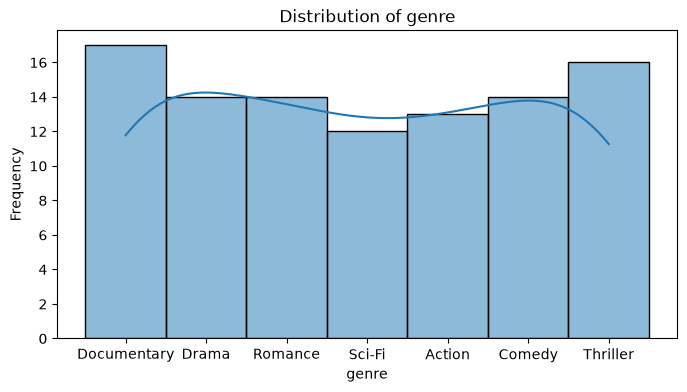

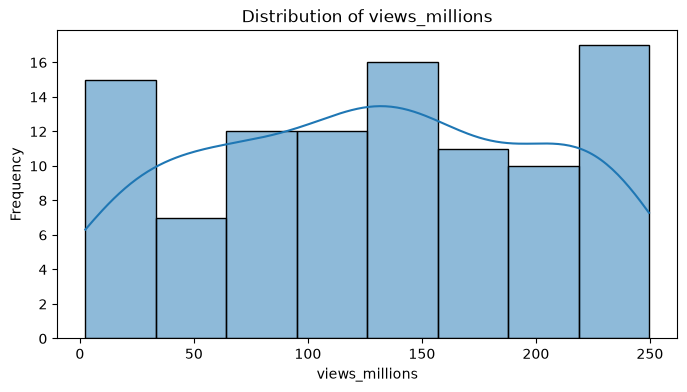

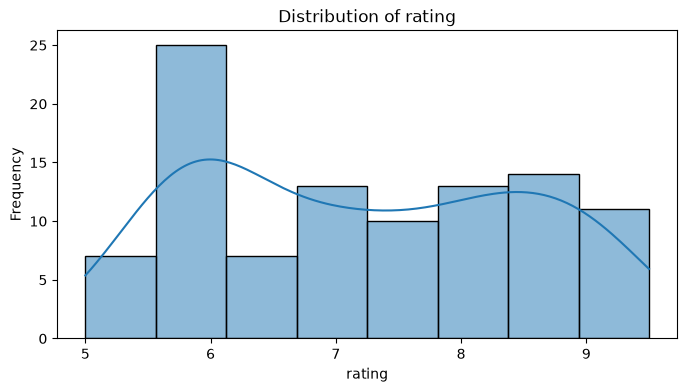

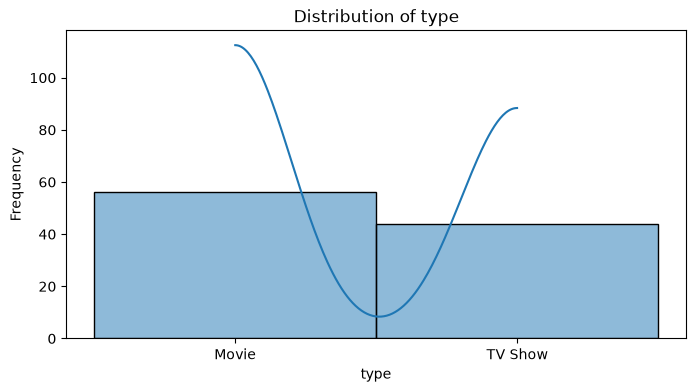

In [16]:
num_cols = ['genre','views_millions','rating','type']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

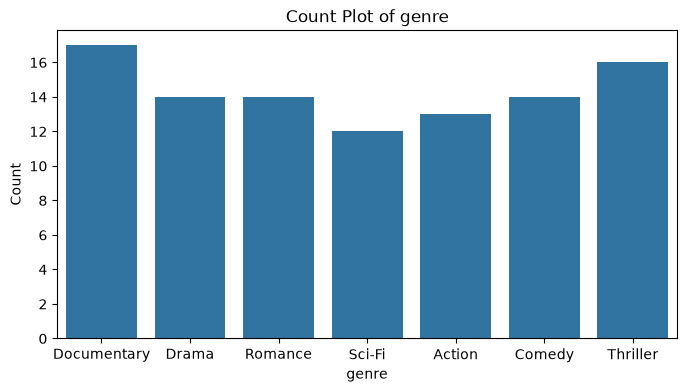

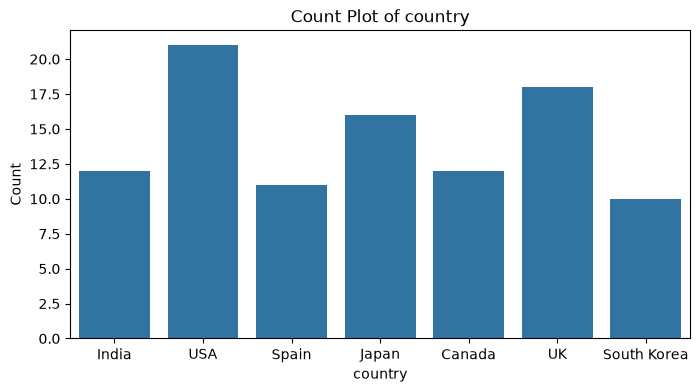

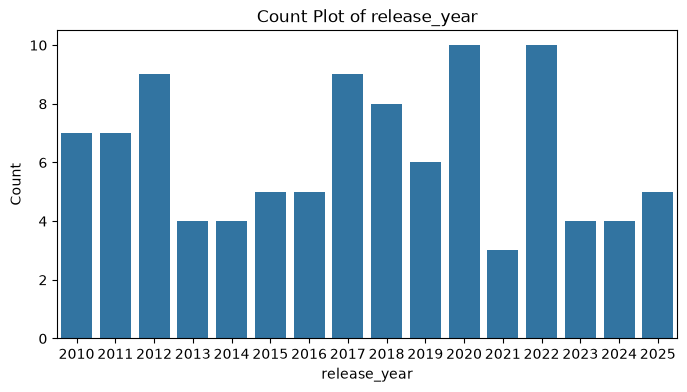

In [25]:
cat_cols = ['genre','country','release_year']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

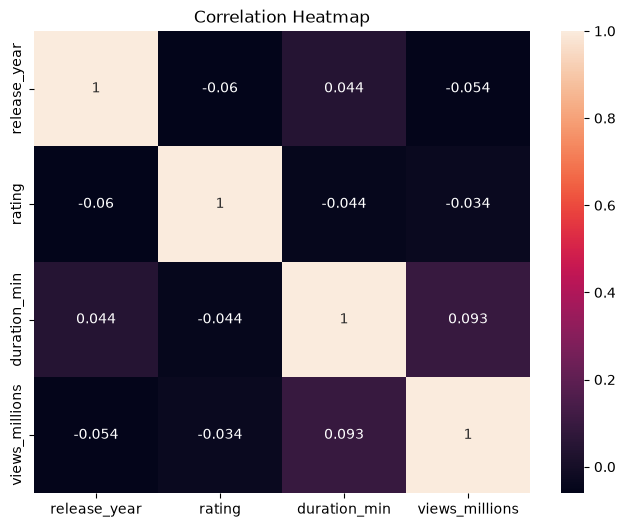

In [10]:
plt.figure(figsize=(8,6))

correlation = df[numerical_columns].corr()

sns.heatmap(
    correlation,
    annot=True,   
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
print("\nAverage Duration Time::")
print(df['duration_min'].mean())

print("\nMaximum Duration Time:")
print(df['duration_min'].max())

print("\nMinimum Duration Time:")
print(df['duration_min'].min())

print("\nAverage Duration Time by genre:")
print(df.groupby('genre')['duration_min'].mean())


Average Duration Time::
118.12

Maximum Duration Time:
180

Minimum Duration Time:
62

Average Duration Time by genre:
genre
Action         134.615385
Comedy         113.285714
Documentary    126.235294
Drama          103.142857
Romance        113.357143
Sci-Fi         102.916667
Thriller       129.000000
Name: duration_min, dtype: float64


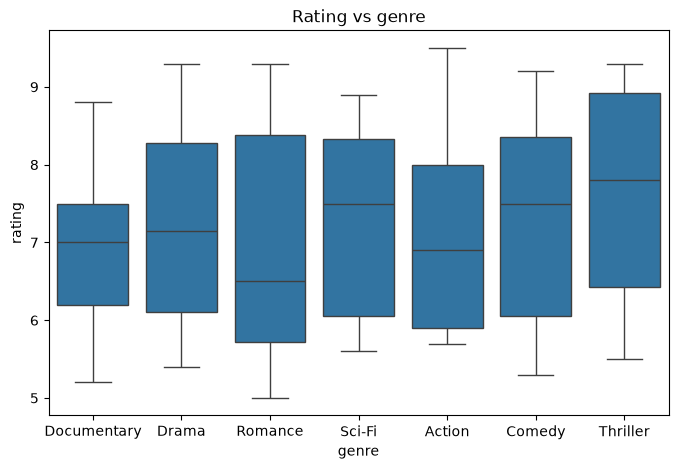

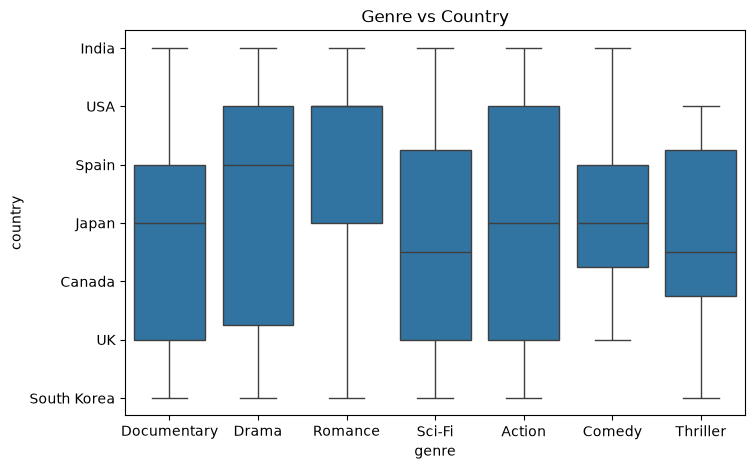

In [23]:
# Rating vs Views millions
plt.figure(figsize=(8,5))
sns.boxplot(x='genre', y='rating', data=df)
plt.title("Rating vs genre")
plt.xlabel("genre")
plt.ylabel("rating")
plt.show()

# Genre vs Country
plt.figure(figsize=(8,5))
sns.boxplot(x='genre', y='country', data=df)
plt.title("Genre vs Country")
plt.xlabel("genre")
plt.ylabel("country")
plt.show()


In [14]:
print("\n========== ANALYSIS SUMMARY ==========")

print("\n1. Average duration time:")
print(df['duration_min'].mean())

print("\nAverage Views:")
print(df['views_millions'].mean())

print("\n2. Average Duration Time by Country:")
print(df.groupby('country')['duration_min'].mean())

print("\n3. Region with Highest Number of Ratings:")
print(df.groupby('country')['rating'].max())

highest_region = df['country'].value_counts().idxmax()
print("\nHighest Number of Genre Region:", highest_region)


========== ANALYSIS SUMMARY ==========

1. Average duration time:
118.12

Average Views:
128.77499999999998

2. Average Duration Time by Country:
country
Canada         123.083333
India          113.083333
Japan          120.000000
South Korea    110.500000
Spain          125.272727
UK             119.333333
USA            115.571429
Name: duration_min, dtype: float64

3. Region with Highest Number of Ratings:
country
Canada         9.0
India          9.0
Japan          9.1
South Korea    8.8
Spain          9.3
UK             9.5
USA            9.3
Name: rating, dtype: float64

Highest Number of Genre Region: USA


In [28]:
print("Interesting Observations:\n" 
"1. The most watched genre is 'Documentry'.\n"
"2. Average duration time in netflix is 118.12 minutes.\n" 
"3. The 'Thriller' genre is rating is highest.\n" 
"4. The most number of movies and th shows are released in 2020.\n"
"5. Region with the highest number of rating is 'Canada'.")

Interesting Observations:
1. The most watched genre is 'Documentry'.
2. Average duration time in netflix is 118.12 minutes.
3. The 'Thriller' genre is rating is highest.
4. The most number of movies and th shows are released in 2020.
5. Region with the highest number of rating is 'Canada'.
